<a href="https://colab.research.google.com/github/arleswasb/Projeto_Final_ED2_RideSmart/blob/main/Projeto_RideSmart.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Modelagem do Trânsito Sintético (`tempo_transito`)

---

Para simular o comportamento de um aplicativo de mobilidade real, os algoritmos do **RideSmart** precisam avaliar o tempo de deslocamento viário sob diferentes condições. Como a rede extraída do OpenStreetMap (`OSMnx`) fornece apenas dados físicos estáticos (comprimento e velocidade regulamentar) , foi implementada uma função de injeção de atributos para calcular dinamicamente o custo temporal de cada via.

A conversão e a ponderação dos pesos seguem o fluxo lógico abaixo:

### 1. Limpeza e Conversão de Unidades

O atributo bruto de velocidade máxima (`maxspeed`) é extraído e convertido de km/h para metros por segundo ($\text{m/s}$), dividindo o valor por $3.6$. Isso garante a consistência dimensional com o comprimento da aresta (`length`), que é fornecido em metros.

### 2. Cálculo do Tempo Base (Sem Trânsito)

Representa o cenário ideal de via livre. O tempo teórico de travessia em segundos é calculado por:

$$\text{tempo\_base} = \frac{\text{length}}{\text{velocidade\_max (m/s)}}$$

### 3. Ponderação por Tipo de Via (Com Trânsito)

Para o cenário com congestionamento, aplica-se um fator multiplicador de lentidão baseado na classificação funcional da rua (`highway`):

$$\text{tempo\_transito} = \text{tempo\_base} \times \text{fator\_de\_lentidão}$$

---


| Tipo de Via (`highway`) | Perfil Real da Via | Fator de Lentidão (Sintético) |
| --- | --- | --- |
| <br>`motorway`, `trunk`, `primary` | Avenidas principais e vias expressas de alta capacidade. | <br>**1.5 a 3.0x** mais lento.
| <br>`secondary`, `tertiary` | Vias coletoras e de conexão interbairros.| <br>**1.2 a 2.0x** mais lento.
| <br>`residential`, `living_street` | Ruas locais de trânsito calmo e residencial. | <br>**1.0 a 1.3x** (próximo ao normal).


---

### Impacto nos Algoritmos

A injeção dessas propriedades permite alternar o comportamento do **Dijkstra** e do **A*** modificando apenas o parâmetro de peso (`weight`) avaliado na busca:

*
**Métrica por Distância:** Utiliza o atributo `length`.


*
**Métrica por Tempo Ideal:** Utiliza o atributo `tempo_base`.


*
**Métrica por Tempo Realista:** Utiliza o atributo `tempo_transito`.



---

## Instalação das Bibliotecas

In [10]:
!pip install osmnx
!pip install networkx
!pip install matplotlib
!pip install numpy

## Download do Mapa e Injeção de Trânsito

In [18]:
import osmnx as ox
import networkx as nx
import random

def inicializar_e_configurar_mapa(localizacao):
    """
    Passo 1: Baixa o mapa real da região.
    Passo 2: Configura os pesos de distância, tempo base e tempo com trânsito.
    """
    print(f"🌍 Baixando o mapa de: {localizacao}...")
    # Baixa a rede de ruas configurada para carros ('drive')
    G_bruto = ox.graph_from_place(localizacao, network_type='drive')

    # Removed the conversion to nx.DiGraph to maintain MultiDiGraph type for osmnx compatibility
    # G = nx.DiGraph(G_bruto)

    print("🚗 Calculando os tempos e injetando o trânsito sintético nas ruas...")

    # Percorre cada rua (aresta) do grafo para aplicar a lógica
    # Adjusted loop for MultiDiGraph (u, v, k, data) and using G_bruto directly
    for u, v, k, data in G_bruto.edges(data=True, keys=True):

        # 1. Obter o comprimento físico da rua (em metros)
        comprimento = data.get('length', 10)

        # 2. Obter e tratar a velocidade máxima (maxspeed)
        max_speed_attr = data.get('maxspeed', 40)

        if isinstance(max_speed_attr, list):
            max_speed_attr = max_speed_attr[0]
        try:
            velocidade_kmh = float(''.join(filter(str.isdigit, str(max_speed_attr))))
        except ValueError:
            velocidade_kmh = 40.0

        # Conversão: km/h para metros por segundo (m/s)
        velocidade_ms = velocidade_kmh / 3.6

        # 3. CÁLCULO DO TEMPO BASE (Sem trânsito)
        data['tempo_base'] = comprimento / velocidade_ms

        # 4. APLICAR FATOR DE TRÂNSITO (Baseado na categoria da rua 'highway')
        tipo_via = data.get('highway', 'residential')
        if isinstance(tipo_via, list):
            tipo_via = tipo_via[0]

        if tipo_via in ['motorway', 'trunk', 'primary']:
            fator_transito = random.uniform(1.5, 3.0)  # Vias principais: muito trânsito
        elif tipo_via in ['secondary', 'tertiary']:
            fator_transito = random.uniform(1.2, 2.0)  # Vias médias: trânsito moderado
        else:
            fator_transito = random.uniform(1.0, 1.3)  # Ruas residenciais: trânsito calmo

        # 5. CÁLCULO DO TEMPO COM TRÂNSITO
        data['tempo_transito'] = data['tempo_base'] * fator_transito

    print("✅ Grafo modelado com sucesso!")
    return G_bruto # Returning G_bruto (MultiDiGraph)


local = "Natal, Rio Grande do Norte, Brazil"
G_projeto = inicializar_e_configurar_mapa(local)

🌍 Baixando o mapa de: Natal, Rio Grande do Norte, Brazil...
🚗 Calculando os tempos e injetando o trânsito sintético nas ruas...
✅ Grafo modelado com sucesso!


### Visualização do Grafo

Agora que o grafo `G_projeto` foi carregado e os atributos de tempo foram injetados, podemos visualizá-lo.

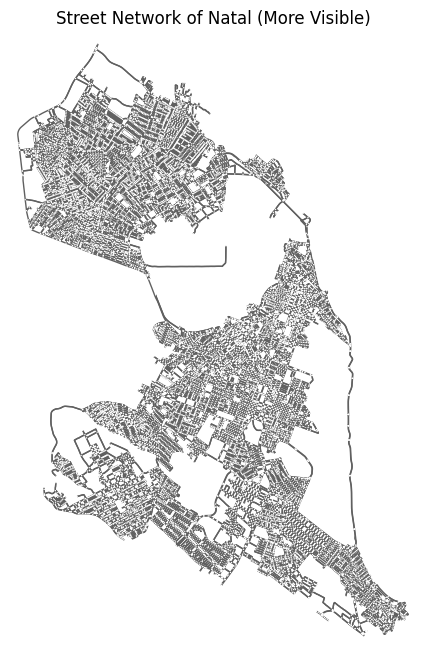

In [21]:
import matplotlib.pyplot as plt

# Visualize the graph with more visible nodes and edges
# Removed 'close=True' to allow further plotting if needed, and setting show=False for clarity
fig, ax = ox.plot_graph(G_projeto, bgcolor='white', node_size=1, edge_color='#606060', edge_linewidth=1, show=False)

plt.title('Street Network of Natal (More Visible)')
plt.show()

### Visualização do Grafo por `tempo_transito`

Para uma visualização mais informativa, podemos colorir as arestas do grafo com base no atributo `tempo_transito`. A cor das arestas representará o tempo de travessia com trânsito, permitindo identificar as vias mais lentas.

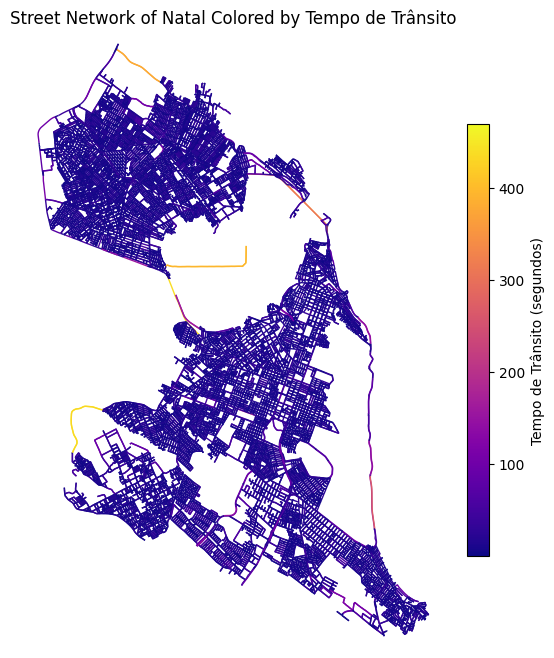

In [25]:
import matplotlib.pyplot as plt

# Get the edge colors based on the 'tempo_transito' attribute
# Normalize the tempo_transito values to a 0-1 range for colormapping
# Directly iterate over G_projeto edges, which is a MultiDiGraph
edges_data = G_projeto.edges(data=True, keys=True)

# Filter out edges without 'tempo_transito' if any, though our function should ensure it's there
tempo_transito_values = [data['tempo_transito'] for u, v, k, data in edges_data if 'tempo_transito' in data]

# Handle case where tempo_transito_values might be empty or have only one unique value
if len(tempo_transito_values) > 1:
    min_val = min(tempo_transito_values)
    max_val = max(tempo_transito_values)
    if max_val == min_val: # Avoid division by zero if all values are the same
        norm = plt.Normalize(vmin=min_val - 1, vmax=max_val + 1)
    else:
        norm = plt.Normalize(vmin=min_val, vmax=max_val)
else:
    norm = plt.Normalize(vmin=0, vmax=1) # Default normalization

# Create a colormap (e.g., 'plasma', 'viridis', 'magma', 'jet')
cmap = plt.cm.plasma

# Assign colors to edges based on 'tempo_transito'
edg_colors = [cmap(norm(data['tempo_transito'])) if 'tempo_transito' in data else '#cccccc' for u, v, k, data in edges_data]

# Plot the graph with colored edges
fig, ax = ox.plot_graph(
    G_projeto,
    bgcolor='white',
    node_size=0,
    edge_color=edg_colors,
    edge_linewidth=1,
    show=False, # Set to False as we will call plt.show() explicitly later
    # Removed close=True to ensure the figure is not closed prematurely
    dpi=300 # Higher DPI for better resolution
)

# Add a colorbar for better interpretation
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array(tempo_transito_values)
cb = fig.colorbar(sm, ax=ax, orientation='vertical', shrink=0.7)
cb.set_label('Tempo de Trânsito (segundos)')

plt.title('Street Network of Natal Colored by Tempo de Trânsito')
plt.show()